# 🥊 Fight Detection dengan MViT_v2_s
## Tutorial Lengkap untuk Pemula - Google Colab

---

### 📋 Yang Akan Kita Lakukan:
1. ✅ Setup environment (mount drive, install dependencies)
2. ✅ Upload Fight_utils_mvit.py
3. ✅ Persiapan dataset (150 fight + 150 noFight)
4. ✅ Training model MViT_v2_s
5. ✅ Testing & download model

### ⏱️ Estimasi Waktu:
- Setup: 10 menit
- Training: 1-2 jam (GPU T4)
- Testing: 5 menit

### 🎯 Expected Result:
- Validation Accuracy: **80-90%**
- Model size: **~150 MB**

---

**📝 Catatan Penting:**
- Pastikan Runtime Type: **GPU** (Runtime → Change runtime type → GPU)
- Dataset sudah disiapkan di Google Drive atau siap upload
- Ikuti setiap cell secara berurutan

---

**Mari kita mulai! 🚀**

# 📦 STEP 1: Setup Environment

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!


In [2]:
# Check GPU
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print("✅ GPU is available!")
else:
    print("⚠️ WARNING: GPU not available. Training will be very slow!")
    print("Please change Runtime Type to GPU: Runtime → Change runtime type → GPU")

Device: cuda:0
GPU: Tesla T4
GPU Memory: 14.56 GB
✅ GPU is available!


In [3]:
# Install required packages
print("📦 Installing dependencies...")
print("This might take 2-3 minutes...\n")

!pip install -q albumentations
!pip install -q moviepy

print("\n✅ All dependencies installed!")

📦 Installing dependencies...
This might take 2-3 minutes...


✅ All dependencies installed!


In [4]:
# Import libraries
import os
import cv2
import time
import copy
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.notebook import tqdm
import albumentations as A
from collections import deque
import matplotlib.pyplot as plt

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 📁 STEP 2: Setup Files & Dataset

## Option B: Copy dari Google Drive (Jika sudah ada di Drive)

In [5]:
# SKIP cell ini jika Anda sudah upload di Option A

# Ganti path ini dengan lokasi file Anda di Google Drive
DRIVE_UTILS_PATH = '/content/drive/MyDrive/fight_detection/Fight_utils_mvit.py'

# Copy dari Drive ke Colab
!cp "{DRIVE_UTILS_PATH}" /content/Fight_utils_mvit.py

print("✅ File copied from Google Drive!")

✅ File copied from Google Drive!


In [6]:
# Verify file exists
if os.path.exists('/content/Fight_utils_mvit.py'):
    print("✅ Fight_utils_mvit.py found!")

    # Show file size
    file_size = os.path.getsize('/content/Fight_utils_mvit.py') / 1024
    print(f"   File size: {file_size:.2f} KB")
else:
    print("❌ ERROR: Fight_utils_mvit.py not found!")
    print("   Please upload the file in Option A or Option B above.")

✅ Fight_utils_mvit.py found!
   File size: 15.92 KB


## Setup Dataset

### 🎯 Pilih salah satu:

**Option 1:** Dataset sudah ada di Google Drive
- Struktur di Drive: `MyDrive/dataset/fight/` dan `MyDrive/dataset/noFight/`
- Jalankan cell di bawah ini dan sesuaikan path

**Option 2:** Upload dataset ke Colab (lebih lambat, tapi simpel)
- Upload folder dataset.zip
- Extract di Colab

In [7]:
# OPTION 1: Dataset di Google Drive (RECOMMENDED)

# 🔧 GANTI PATH INI sesuai lokasi dataset Anda di Google Drive
DATASET_DIR = '/content/drive/MyDrive/fight_detection'

# Cek apakah dataset ada
if os.path.exists(DATASET_DIR):
    fight_path = os.path.join(DATASET_DIR, 'fight')
    nofight_path = os.path.join(DATASET_DIR, 'noFight')

    if os.path.exists(fight_path) and os.path.exists(nofight_path):
        num_fight = len(os.listdir(fight_path))
        num_nofight = len(os.listdir(nofight_path))

        print("✅ Dataset found!")
        print(f"   Fight videos: {num_fight}")
        print(f"   NoFight videos: {num_nofight}")
        print(f"   Total: {num_fight + num_nofight}")

        if num_fight < 50 or num_nofight < 50:
            print("\n WARNING: Dataset terlalu kecil!")
            print("   Minimal 100 video per kelas untuk hasil baik.")
    else:
        print(" ERROR: Folder 'fight' atau 'noFight' tidak ditemukan!")
        print(f"   Expected: {fight_path} dan {nofight_path}")
else:
    print(" ERROR: Dataset directory not found!")
    print(f"   Path: {DATASET_DIR}")
    print("\n Solusi:")
    print("   1. Pastikan path benar")
    print("   2. Atau gunakan Option 2 untuk upload dataset")

✅ Dataset found!
   Fight videos: 150
   NoFight videos: 150
   Total: 300


# 🔧 STEP 3: Import Fight Utilities

In [9]:
!pip install pytube


In [10]:
# Import Fight_utils_mvit
import sys
sys.path.append('/content')

from Fight_utils_mvit import (
    create_dataset,
    create_fresh_mvit_model,
    device,
    CLASSES_LIST,
    SEQUENCE_LENGTH
)

print("✅ Fight_utils_mvit imported successfully!")
print(f"   Device: {device}")
print(f"   Classes: {CLASSES_LIST}")
print(f"   Sequence Length: {SEQUENCE_LENGTH}")

✅ Fight_utils_mvit imported successfully!
   Device: cuda:0
   Classes: ['fight', 'noFight']
   Sequence Length: 16


# 🎓 STEP 4: Load & Prepare Dataset

In [11]:
# Set random seed for reproducibility
seed_constant = 42
np.random.seed(seed_constant)
random.seed(seed_constant)
torch.manual_seed(seed_constant)
torch.cuda.manual_seed_all(seed_constant)

print("✅ Random seed set to:", seed_constant)

✅ Random seed set to: 42


In [12]:
# Load dataset
print("="*80)
print(" LOADING DATASET")
print("="*80)
print(" Extracting frames from videos...")
print("   This will take 20-40 minutes for 300 videos.")
print("   Please be patient!\n")

start_time = time.time()

# Extract features and labels
features, labels = create_dataset(DATASET_DIR, CLASSES_LIST, SEQUENCE_LENGTH)

elapsed = time.time() - start_time

print(f"\n{'='*80}")
print("✅ DATASET LOADED SUCCESSFULLY!")
print(f"{'='*80}")
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Time taken: {elapsed/60:.1f} minutes")

  A.Resize(256, 256, always_apply=True),  # Resize lebih besar dulu

  A.CenterCrop(224, 224, always_apply=True),  # Center crop ke 224x224

  A.Normalize(



 LOADING DATASET
 Extracting frames from videos...
   This will take 20-40 minutes for 300 videos.
   Please be patient!

Extracting Data of Class: fight
Extracting Data of Class: noFight

✅ DATASET LOADED SUCCESSFULLY!
Features shape: torch.Size([300, 3, 16, 224, 224])
Labels shape: torch.Size([300])
Time taken: 5.3 minutes


In [14]:
# Split dataset
print("\n Splitting dataset...")

# Configuration
VALIDATION_SPLIT = 0.2  # 20% for validation
BATCH_SIZE = 4          # Adjust if OOM error

# Create dataset
full_dataset = TensorDataset(features, labels)

# Calculate split sizes
total_size = len(full_dataset)
val_size = int(VALIDATION_SPLIT * total_size)
train_size = total_size - val_size

# Split
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed_constant)
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

dataloaders = {'train': train_loader, 'val': val_loader}

print(f"✅ Dataset split complete!")
print(f"   Total: {total_size} videos")
print(f"   Training: {train_size} videos ({(1-VALIDATION_SPLIT)*100:.0f}%)")
print(f"   Validation: {val_size} videos ({VALIDATION_SPLIT*100:.0f}%)")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches per epoch (train): {len(train_loader)}")
print(f"   Batches per epoch (val): {len(val_loader)}")


 Splitting dataset...
✅ Dataset split complete!
   Total: 300 videos
   Training: 240 videos (80%)
   Validation: 60 videos (20%)
   Batch size: 4
   Batches per epoch (train): 60
   Batches per epoch (val): 15


In [15]:
# Clear memory
torch.cuda.empty_cache()
print("✅ GPU memory cleared")

✅ GPU memory cleared


# 🤖 STEP 5: Create Model

In [16]:
print("="*80)
print("🤖 CREATING MViT_v2_s MODEL")
print("="*80)
print("⏳ Loading pretrained weights from Kinetics-400...")
print("   This might take 2-3 minutes...\n")

# Create model
model = create_fresh_mvit_model(num_classes=2, pretrained=True)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n{'='*80}")
print("✅ MODEL CREATED SUCCESSFULLY!")
print(f"{'='*80}")
print(f"Model: MViT_v2_s")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB")
print(f"Device: {device}")
print(f"{'='*80}")

🤖 CREATING MViT_v2_s MODEL
⏳ Loading pretrained weights from Kinetics-400...
   This might take 2-3 minutes...

Downloading: "https://download.pytorch.org/models/mvit_v2_s-ae3be167.pth" to /root/.cache/torch/hub/checkpoints/mvit_v2_s-ae3be167.pth


100%|██████████| 132M/132M [00:00<00:00, 177MB/s]



✅ MODEL CREATED SUCCESSFULLY!
Model: MViT_v2_s
Total parameters: 34,231,682
Trainable parameters: 34,231,682
Model size: ~130.6 MB
Device: cuda:0


# 🚀 STEP 6: Training Configuration

In [17]:
# Training configuration
NUM_EPOCHS = 40
LEARNING_RATE = 0.0001
WEIGHT_DECAY = 1e-3

# Loss function with Label Smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

# Optimizer with Weight Decay (AdamW)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler (CosineAnnealing for smooth decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)

print("="*80)
print("⚙️ TRAINING CONFIGURATION")
print("="*80)
print(f"Number of epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Optimizer: AdamW")
print(f"Loss function: CrossEntropyLoss (Label Smoothing=0.15)")
print(f"LR Scheduler: CosineAnnealingWarmRestarts")
print("="*80)


⚙️ TRAINING CONFIGURATION
Number of epochs: 40
Learning rate: 0.0001
Weight Decay: 0.001
Batch size: 4
Optimizer: AdamW
Loss function: CrossEntropyLoss (Label Smoothing=0.15)
LR Scheduler: CosineAnnealingWarmRestarts


# 🎓 STEP 7: Training Loop

**⏱️ Estimasi waktu:** 1-2 jam (tergantung GPU)

**Tips:**
- Anda bisa minimize tab ini, training akan tetap berjalan
- Jangan close tab/browser!
- Jika Colab disconnect, model terakhir tetap tersimpan
- Monitor progress bar dan metrics

In [18]:
# Training function (simplified dari Fight_utils)
def train_model_colab(model, dataloaders, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")

        # Each epoch has training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            # Progress bar
            pbar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()}', leave=False)

            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar
                pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{torch.sum(preds == labels.data).item() / inputs.size(0):.4f}'
                })

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            # Save to history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

            # Save best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'🌟 New best model! (Val Acc: {best_acc:.4f})')

            # Update scheduler
            if phase == 'val':
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(epoch_acc)
                else:
                    scheduler.step()

        # Time estimation
        elapsed = time.time() - since
        avg_time = elapsed / (epoch + 1)
        remaining = avg_time * (num_epochs - epoch - 1)
        print(f'⏱️ Time: {elapsed/60:.1f}m elapsed, ~{remaining/60:.1f}m remaining')

    time_elapsed = time.time() - since
    print(f"\n{'='*80}")
    print(f"✅ TRAINING COMPLETE!")
    print(f"{'='*80}")
    print(f'Training completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best validation accuracy: {best_acc:.4f}')
    print(f"{'='*80}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

print("✅ Training function ready!")

✅ Training function ready!


In [19]:
# START TRAINING!
print("="*80)
print("🚀 STARTING TRAINING")
print("="*80)
print("Tips:")
print("  • You can minimize this tab, training will continue")
print("  • Don't close the browser!")
print("  • Monitor the progress bars")
print("  • Expected time: 1-2 hours")
print("="*80)

input("\n⚠️ Press Enter to start training...")

# Train the model
trained_model, history = train_model_colab(
    model=model,
    dataloaders=dataloaders,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS
)

🚀 STARTING TRAINING
Tips:
  • You can minimize this tab, training will continue
  • Don't close the browser!
  • Monitor the progress bars
  • Expected time: 1-2 hours

⚠️ Press Enter to start training...

Epoch 1/40


Train:   0%|          | 0/60 [00:00<?, ?it/s]

Train Loss: 0.5963 | Acc: 0.6875


Val:   0%|          | 0/15 [00:00<?, ?it/s]

Val Loss: 0.4034 | Acc: 0.9333
🌟 New best model! (Val Acc: 0.9333)
⏱️ Time: 1.1m elapsed, ~42.6m remaining

Epoch 2/40


...

Val Loss: 0.3603 | Acc: 0.9500
⏱️ Time: 46.6m elapsed, ~1.2m remaining

Epoch 40/40


Train:   0%|          | 0/60 [00:00<?, ?it/s]

Train Loss: 0.3398 | Acc: 0.9500


Val:   0%|          | 0/15 [00:00<?, ?it/s]

Val Loss: 0.4525 | Acc: 0.8167
⏱️ Time: 47.8m elapsed, ~0.0m remaining

✅ TRAINING COMPLETE!
Training completed in 47m 48s
Best validation accuracy: 0.9833


# 📊 STEP 8: Visualize Training Results

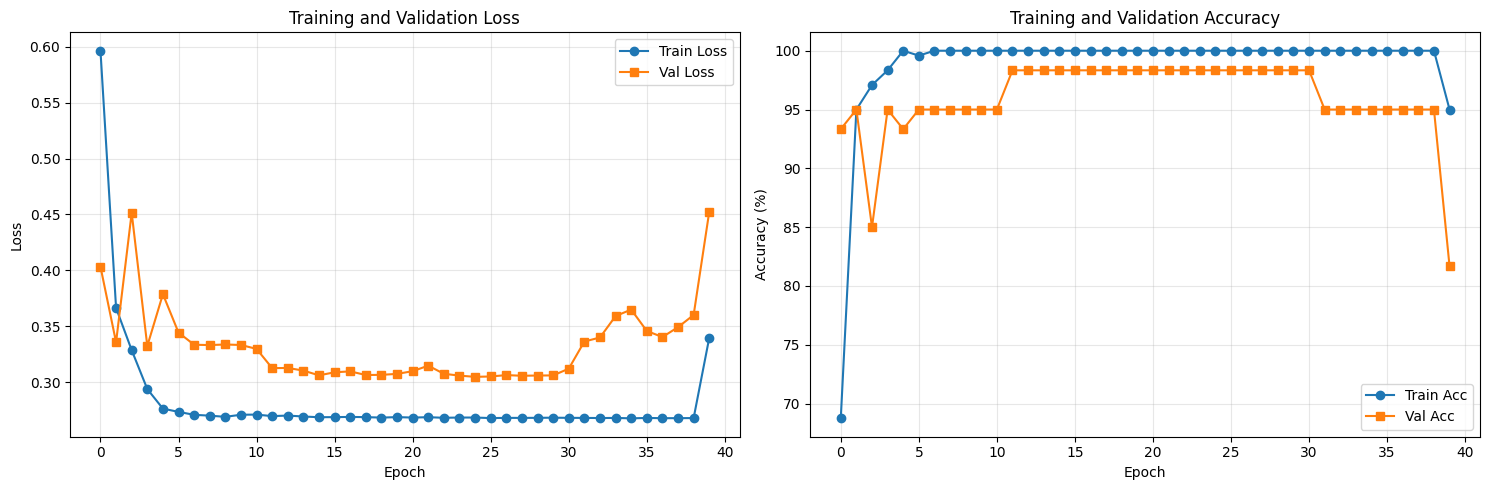

✅ Training curves saved as 'training_curves.png'


In [20]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot([acc*100 for acc in history['train_acc']], label='Train Acc', marker='o')
ax2.plot([acc*100 for acc in history['val_acc']], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved as 'training_curves.png'")

In [21]:
# Print final metrics
print("="*80)
print("📈 TRAINING SUMMARY")
print("="*80)

final_train_acc = history['train_acc'][-1] * 100
final_val_acc = history['val_acc'][-1] * 100
best_val_acc = max(history['val_acc']) * 100

print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

# Interpretasi
print(f"\n{'='*80}")
print("💡 INTERPRETASI")
print(f"{'='*80}")

if best_val_acc >= 90:
    print("🎉 EXCELLENT! Model sangat bagus!")
elif best_val_acc >= 80:
    print("👍 GOOD! Model cukup bagus untuk production.")
elif best_val_acc >= 70:
    print("⚠️ FAIR. Model bisa ditingkatkan dengan:")
    print("   • Training lebih lama")
    print("   • Tambah data")
    print("   • Data augmentation")
else:
    print("❌ NEEDS IMPROVEMENT. Coba:")
    print("   • Periksa kualitas dataset")
    print("   • Tambah lebih banyak data")
    print("   • Adjust learning rate")

# Check overfitting
train_val_gap = final_train_acc - final_val_acc
if train_val_gap > 10:
    print(f"\n⚠️ WARNING: Model mungkin overfitting!")
    print(f"   Gap: {train_val_gap:.2f}%")
    print("   Solusi: Tambah data atau gunakan regularization")

print("="*80)

📈 TRAINING SUMMARY
Final Training Accuracy: 95.00%
Final Validation Accuracy: 81.67%
Best Validation Accuracy: 98.33%

💡 INTERPRETASI
🎉 EXCELLENT! Model sangat bagus!

⚠️ WARNING: Model mungkin overfitting!
   Gap: 13.33%
   Solusi: Tambah data atau gunakan regularization


# 💾 STEP 9: Save Model

In [22]:
# Save model to Colab
MODEL_SAVE_PATH = '/content/mvit_fight_modelV2.pth'

torch.save(trained_model.state_dict(), MODEL_SAVE_PATH)

print("="*80)
print("💾 MODEL SAVED")
print("="*80)
print(f"Path: {MODEL_SAVE_PATH}")

# Check file size
model_size = os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024
print(f"Size: {model_size:.1f} MB")
print("="*80)

💾 MODEL SAVED
Path: /content/mvit_fight_modelV2.pth
Size: 130.7 MB


In [23]:
# Save to Google Drive (RECOMMENDED)
DRIVE_SAVE_PATH = '/content/drive/MyDrive/mvit_fight_modelV2.pth'

print("💾 Saving model to Google Drive...")
!cp /content/mvit_fight_model.pth "{DRIVE_SAVE_PATH}"

print(f"\n✅ Model saved to Google Drive!")
print(f"Path: {DRIVE_SAVE_PATH}")
print("\n💡 Model Anda aman di Google Drive!")

💾 Saving model to Google Drive...
cp: cannot stat '/content/mvit_fight_model.pth': No such file or directory

✅ Model saved to Google Drive!
Path: /content/drive/MyDrive/mvit_fight_modelV2.pth

💡 Model Anda aman di Google Drive!


In [24]:
# Download model to local computer
from google.colab import files

print("📥 Downloading model to your computer...")
files.download(MODEL_SAVE_PATH)

print("\n✅ Model downloaded!")
print("   Check your Downloads folder.")

📥 Downloading model to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Model downloaded!
   Check your Downloads folder.


## 📊 Confusion Matrix

📈 Generating Confusion Matrix...


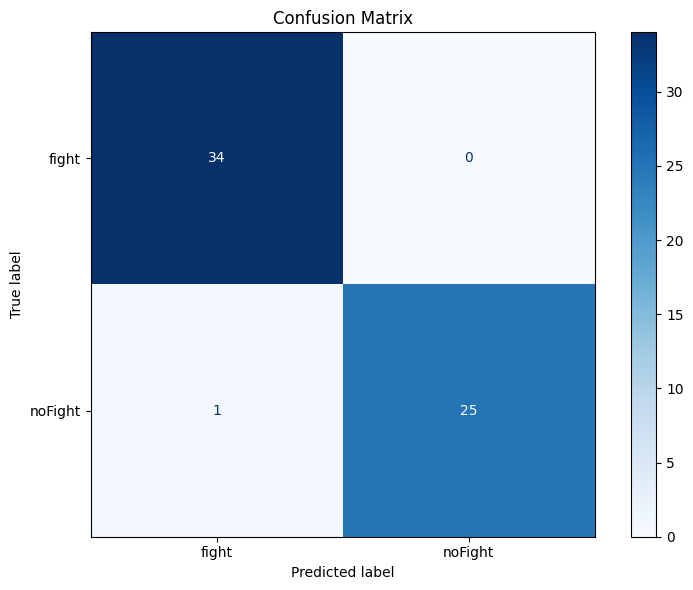


✅ Confusion Matrix generated and saved as 'confusion_matrix.png'!


In [25]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("📈 Generating Confusion Matrix...")

# Set model to evaluation mode
trained_model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = trained_model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions, labels=list(range(len(CLASSES_LIST))))

# Display confusion matrix
fig_cm, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion Matrix generated and saved as 'confusion_matrix.png'!")

In [26]:
from sklearn.metrics import classification_report

# Mengeluarkan laporan metrik evaluasi lengkap
print("\\n--- LAPORAN METRIK EVALUASI (BAB 4) ---")
laporan = classification_report(all_labels, all_predictions, target_names=CLASSES_LIST, digits=4)
print(laporan)

\n--- LAPORAN METRIK EVALUASI (BAB 4) ---
              precision    recall  f1-score   support

       fight     0.9714    1.0000    0.9855        34
     noFight     1.0000    0.9615    0.9804        26

    accuracy                         0.9833        60
   macro avg     0.9857    0.9808    0.9829        60
weighted avg     0.9838    0.9833    0.9833        60



# 🧪 STEP 10: Testing (Quick Test)

In [ ]:
import torch
import os
from google.colab import drive

print(">>> Menyambungkan ke Google Drive...")
drive.mount('/content/drive')

model_filename = '/content/drive/MyDrive/mvit_fight_modelV2.pth'

if os.path.exists(model_filename):
    print(f"Mantap! Berhasil menemukan model: {model_filename}")
else:
    print(f"Waduh, file nggak ketemu nih. Pastikan letak dan nama foldernya udah bener ya: {model_filename}")

In [ ]:
from google.colab import files
from Fight_utils_mvit import Fight_PipeLine # Wajib di-import di sini!

print("\n📤 Silakan upload video CCTV (MP4/AVI) yang mau dites:")
uploaded = files.upload()

# Cek apakah user beneran upload file
if uploaded:
    test_video = list(uploaded.keys())[0]
    print(f"🎥 Video '{test_video}' berhasil diterima. AI mulai menganalisis, tunggu sebentar ya...")

    # Tentukan nama file hasil
    output_video = f"result_{test_video}"

    # Eksekusi AI (ngambil alamat model dari Cell 1)
    Fight_PipeLine(
        modelPath=model_path_gdrive,
        inputPath=test_video,
        seq=16,
        skip=2,
        outputPath=output_video,
        showInfo=True
    )

    print("\n📥 Analisis selesai! Sedang mengunduh video hasil...")
    files.download(output_video)
    print("🎉 Sempurna! Cek video hasilnya di laptopmu ya komandan!")
else:
    print("⚠️ Eh, kamu belum milih video buat di-upload nih. Coba run lagi ya.")